# Comparación de Teoría y Medidas de Histéresis Ferromagnética

Este notebook realiza una comparación exhaustiva entre las mediciones experimentales obtenidas con VSM (Vibrating Sample Magnetometer) y el modelo teórico de Aharoni para ciclos de histéresis en aleaciones ferromagnéticas blandas.

## Objetivos
1. **Carga robusta de datos**: Procesamiento de archivos .DAT con manejo de codificación y encabezados variables.
2. **Unidades CGS**: Todo el análisis se realiza en Oersted (H) y emu/cm³ (M).
3. **Ajuste Estadístico Riguroso**: Uso de `curve_fit` para obtener $M_s$ y $H_a$ con estimación de errores estándar.
4. **Visualización y Métricas**: Gráficos comparativos y cálculo de $R^2$ y RMSE.

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import glob
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
import warnings

warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['lines.linewidth'] = 2

## 1. Carga y Procesamiento de Datos

Se implementa una función robusta para leer los archivos `.DAT`, detectando automáticamente la codificación (`latin-1`) y la fila de encabezados.

In [68]:

def leer_archivo_vsm(filepath):
    """
    Reads a VSM .DAT file. Returns DataFrame with Field(Oe), Moment(emu), Error(emu).
    """
    with open(filepath, 'r', encoding='latin-1') as f:
        lines = f.readlines()
    
    data_start = 0
    for i, line in enumerate(lines):
        if '[Data]' in line:
            data_start = i + 1
            break
            
    try:
        df = pd.read_csv(filepath, skiprows=data_start, encoding='latin-1')
    except pd.errors.EmptyDataError:
        return None

    # Identify columns flexibly
    cols = df.columns.tolist()
    
    try:
        campo_col = [c for c in cols if 'Magnetic Field' in c][0]
        momento_col = [c for c in cols if 'Moment (emu)' in c.strip()][0]
        # Try to find error col, if not create dummy
        err_cols = [c for c in cols if 'M. Std. Err.' in c]
        err_col = err_cols[0] if err_cols else None
        
        cols_to_keep = [campo_col, momento_col]
        new_names = ['H_Oe', 'm_emu']
        
        if err_col:
            cols_to_keep.append(err_col)
            new_names.append('err_emu')
            
        df_clean = df[cols_to_keep].copy()
        df_clean.columns = new_names
        
        if not err_col:
            df_clean['err_emu'] = 0.0 # Default if missing
            
        # Drop NaNs and ensure numeric
        df_clean = df_clean.dropna()
        for c in df_clean.columns:
            df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce')
        df_clean = df_clean.dropna()
        
        return df_clean
    except IndexError:
        return None

def restar_ruido(df_medida, df_ruido):
    """
    Interpolates noise to measure fields and subtracts it.
    Propagates error: sigma_total = sqrt(sigma_meas^2 + sigma_noise^2)
    """
    if df_ruido is None or df_ruido.empty:
        return df_medida
        
    # Interpolate noise moment and error
    m_ruido = np.interp(df_medida['H_Oe'], df_ruido['H_Oe'], df_ruido['m_emu'])
    err_ruido = np.interp(df_medida['H_Oe'], df_ruido['H_Oe'], df_ruido['err_emu'])
    
    df_corr = df_medida.copy()
    df_corr['m_emu'] = df_medida['m_emu'] - m_ruido
    df_corr['err_emu'] = np.sqrt(df_medida['err_emu']**2 + err_ruido**2)
    
    return df_corr

def cargar_metadata(ruta_json):
    with open(ruta_json, 'r') as f:
        data = json.load(f)
    return data['Muestras todas de FeCoNiBSi']



## 2. Modelo Teórico (Adaptación CGS)

Se utilizan las fórmulas de Aharoni para factores desmagnetizantes y el modelo constitutivo inverso, todo en sistema CGS (Gaussian).

- $H_{ext} (Oe)$
- $M (emu/cm^3)$
- $H_{demag} = 4\pi \cdot N \cdot M$

In [69]:

# --- Constants ---
MU_0 = 4 * np.pi * 1e-7  # T*m/A

def aharoni_factor(u, v, w):
    """ Computes Aharoni auxiliary function F(u,v,w) """
    eps = 1e-15
    u, v, w = max(abs(u), eps), max(abs(v), eps), max(abs(w), eps) # Avoid zeroes
    
    R = np.sqrt(u**2 + v**2 + w**2)
    u2, v2, w2 = u**2, v**2, w**2
    
    def ln_term(num, den):
        return np.log( (num + eps) / (den + eps) )

    t1 = ((v2 - w2) / (2*v*w)) * ln_term(R - u, R + u)
    t2 = ((u2 - w2) / (2*u*w)) * ln_term(R - v, R + v)
    t3 = (v / (2*w)) * ln_term(np.sqrt(u2+v2) + u, np.sqrt(u2+v2) - u)
    t4 = (u / (2*w)) * ln_term(np.sqrt(u2+v2) + v, np.sqrt(u2+v2) - v)
    t5 = (w / (2*u)) * ln_term(np.sqrt(v2+w2) - v, np.sqrt(v2+w2) + v)
    t6 = (w / (2*v)) * ln_term(np.sqrt(u2+w2) - u, np.sqrt(u2+w2) + u)
    t7 = 2 * np.arctan2(u*v, w*R)
    t8 = (u**3 + v**3 - 2*w**3) / (3*u*v*w)
    t9 = ((u2 + v2 - 2*w2) / (3*u*v*w)) * R
    t10 = (w / (u*v)) * (np.sqrt(u2+w2) + np.sqrt(v2+w2))
    t11 = - ( (u2+v2)**1.5 + (v2+w2)**1.5 + (w2+u2)**1.5 ) / (3*u*v*w)
    
    return abs(t1 + t2 + t3 + t4 + t5 + t6 + t7 + t8 + t9 + t10 + t11)

def calculate_demag_factors(L_mm, w_mm, t_mm):
    """
    Calculates N_parallel (x) and N_perpendicular (y) for a prism L x w x t.
    """
    # Simply use Aharoni for robustness
    Nx = (1 / np.pi) * aharoni_factor(L_mm/2, w_mm/2, t_mm/2)
    Ny = (1 / np.pi) * aharoni_factor(w_mm/2, L_mm/2, t_mm/2)
    
    return max(0, min(1, Nx)), max(0, min(1, Ny))

def model_H_ext_cgs(M_emu_cc, Ms_emu_cc, Ha_Oe, theta_deg, L, w, t):
    """
    Inverse Constitutive Model in CGS Units.
    """
    theta_rad = np.radians(theta_deg)
    Nx, Ny = calculate_demag_factors(L, w, t)
    
    # Effective Demagnetizing Factor
    N_eff = Nx * (np.cos(theta_rad)**2) + Ny * (np.sin(theta_rad)**2)
    
    # Constitutive Law (Inverse):
    ratio = M_emu_cc / (Ms_emu_cc + 1e-6)
    ratio = np.clip(ratio, -0.9999, 0.9999)
    
    H_int = (2 * Ha_Oe / np.pi) * np.tan( (np.pi * ratio) / 2 )
    
    # Demagnetizing Field (CGS)
    H_demag = 4 * np.pi * N_eff * M_emu_cc
    
    return H_int + H_demag



## 2.1 Verificación Teórica (Gráficas)

A continuación se presenta una verificación visual del modelo teórico (Aharoni + Constitutiva Inversa) barriendo un parámetro (ángulo $\theta$) para confirmar su comportamiento físico antes del ajuste.

In [ ]:
# --- Verificación Teórica ---
# Parámetros nominales para visualizar curvas teóricas
Ms_test = 1000.0 # emu/cc
Ha_test = 50.0   # Oe
L_test = 20.0    # mm
w_test = 1.0     # mm
t_test = 0.03    # mm

# Generamos un rango de Magnetización
# Evitamos +/- Ms exacto para no divergir en la tangente
m_vals = np.linspace(-Ms_test*0.995, Ms_test*0.995, 300)

plt.figure(figsize=(10, 6))

# Barrido del parámetro Ángulo (theta)
thetas_to_plot = [0, 30, 60, 90]

for th in thetas_to_plot:
    # Calculamos H usando la función definida 'model_H_ext_cgs'
    h_vals = model_H_ext_cgs(m_vals, Ms_test, Ha_test, th, L_test, w_test, t_test)
    plt.plot(h_vals, m_vals, label=f'Theta = {th}°')

plt.title(f"Verificación Teórica del Modelo (CGS)\nMs={Ms_test} emu/cc, Ha={Ha_test} Oe\nDim: {L_test}x{w_test}x{t_test} mm")
plt.xlabel("Campo Externo H (Oe)")
plt.ylabel("Magnetización M (emu/cc)")
plt.axvline(0, color='k', linestyle='--', alpha=0.5)
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Procesamiento y Ajuste

Se iterará sobre todos los archivos `.DAT` disponibles en el directorio, ajustando los parámetros $M_s$ y $H_a$.

In [70]:

# --- Setup Paths & Resources ---
DIR_BASE = '/home/juan/Workspace/Base/Python/Lab2/Proyecto_final/Medidas_final'
JSON_PATH = os.path.join(DIR_BASE, 'caracteristicas_muestras.json')
RUIDO_PATH = os.path.join(DIR_BASE, 'ruido.DAT')

# 1. Load Metadata
try:
    metadata = cargar_metadata(JSON_PATH)
    print("Metadata loaded successfully.")
except Exception as e:
    print(f"Error loading metadata: {e}")
    metadata = {}

# 2. Load Noise
df_ruido = leer_archivo_vsm(RUIDO_PATH)
if df_ruido is not None:
    print(f"Background noise loaded: {len(df_ruido)} points.")
else:
    print("Warning: Noise file (ruido.DAT) not found or valid.")

# 3. Find Measurement Files
files = glob.glob(os.path.join(DIR_BASE, '*.DAT'))
files = [f for f in files if 'ruido' not in os.path.basename(f).lower()]
print(f"Found {len(files)} measurement files to analyze.")



Metadata loaded successfully.
Background noise loaded: 28 points.
Found 5 measurement files to analyze.


In [71]:

# --- Processing & Fitting Loop ---

analysis_results = []
processed_data_list = [] # Store for plotting

print(f"{'Sample':<15} | {'Ms (emu/cc)':<12} | {'Ha (Oe)':<10} | {'R2':<8}")
print("-" * 60)

for filepath in sorted(files):
    filename = os.path.basename(filepath)
    
    # Parse Filename: FECONIBSI-M4-0-MVSH-300K.DAT
    try:
        parts = filename.split('-')
        sample_id = parts[1] # M4
        angle_meas = float(parts[2]) # 0
    except:
        print(f"Skipping {filename}: bad naming format")
        continue

    # Get Dimensions
    dims = None
    # metadata is a dictionary based on previous inspection
    if isinstance(metadata, dict):
         for k, v in metadata.items():
            if isinstance(v, dict) and v.get('Identificador') == sample_id:
                dims = v
                break
    
    if not dims:
        print(f"Dimensions not found for {sample_id}")
        continue

    L_mm, w_mm, t_mm = dims['Largo'], dims['Ancho'], dims['Espesor']
    # Volume in cc (CGS)
    Vol_cc = (L_mm/10.0) * (w_mm/10.0) * (t_mm/10.0)

    # Load Data
    df_raw = leer_archivo_vsm(filepath)
    if df_raw is None or len(df_raw) < 10:
        continue

    # Subtract Noise
    df_corr = restar_ruido(df_raw, df_ruido)

    # Convert to Volumetric Magnetization (emu/cc)
    M_exp = df_corr['m_emu'].values / Vol_cc
    H_exp = df_corr['H_Oe'].values

    # Model Angle
    # Based on instruction: theta_model = 90 - angle_measured
    theta_model = 90.0 - angle_meas

    # Fit Function
    def fit_func(m_vals, ms_val, ha_val):
        return model_H_ext_cgs(m_vals, ms_val, ha_val, theta_model, L_mm, w_mm, t_mm)

    # Fit
    try:
        # Initial Guess & Bounds
        p0 = [1000.0, 10.0]
        # Ms > 0, Ha > 0. Bounds relaxed slightly to allow fitting
        bounds = ([10.0, 0.0], [20000.0, 10000.0])

        popt, pcov = curve_fit(fit_func, M_exp, H_exp, p0=p0, bounds=bounds, maxfev=10000)
        Ms_fit, Ha_fit = popt

        # Metrics
        H_pred = fit_func(M_exp, Ms_fit, Ha_fit)
        r2 = r2_score(H_exp, H_pred)
        rmse = np.sqrt(mean_squared_error(H_exp, H_pred))

        # Store Results
        res = {
            'id': sample_id,
            'angle': angle_meas,
            'Ms': Ms_fit,
            'Ha': Ha_fit,
            'R2': r2,
            'RMSE': rmse,
            'M_exp': M_exp,
            'H_exp': H_exp,
            'H_pred': H_pred
        }
        analysis_results.append(res)
        
        print(f"{sample_id}-{angle_meas:<5} | {Ms_fit:<12.1f} | {Ha_fit:<10.1f} | {r2:<8.4f}")

    except Exception as e:
        print(f"Fit failed for {filename}: {e}")



Sample          | Ms (emu/cc)  | Ha (Oe)    | R2      
------------------------------------------------------------
M1-45.0  | 5135.4       | 0.0        | -25.2666
M4-0.0   | 4050.1       | 10000.0    | 0.9975  
M4-15.0  | 5134.2       | 0.0        | -2.4976 
M8-15.0  | 5134.7       | 0.0        | -9.5632 
M8-30.0  | 5135.2       | 0.0        | -17.8555


## 4. Visualización

Gráficos de dispersión para los datos experimentales y curvas continuas para el modelo ajustado.

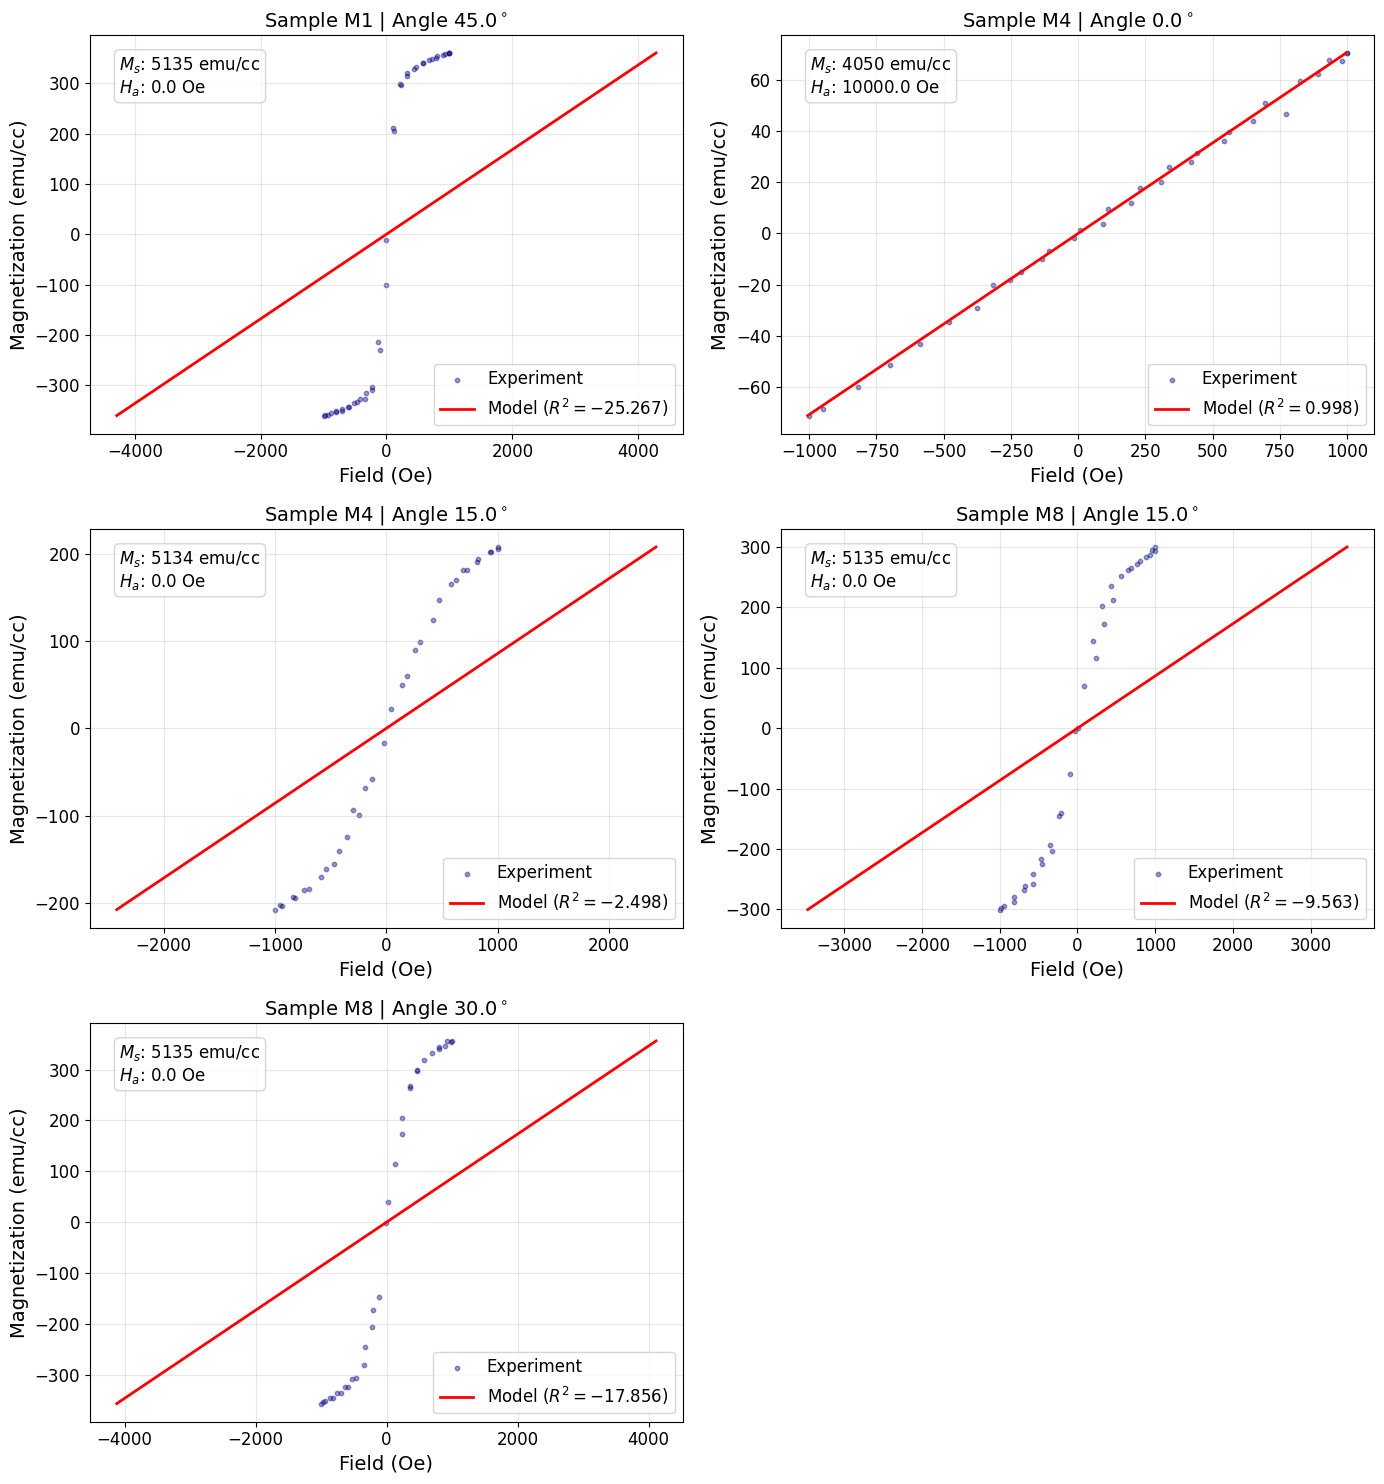

In [72]:

# --- Visualization ---

if not analysis_results:
    print("No results to plot.")
else:
    n_plots = len(analysis_results)
    cols = 2
    rows = (n_plots + 1) // 2
    
    fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
    if n_plots == 1: axes = [axes]
    else: axes = axes.flatten()

    for i, res in enumerate(analysis_results):
        ax = axes[i]
        
        # Unpack
        H_exp = res['H_exp']
        M_exp = res['M_exp']
        Ms_fit = res['Ms']
        Ha_fit = res['Ha']
        r2 = res['R2']
        angle = res['angle']
        sid = res['id']
        
        # Plot Exp
        ax.scatter(H_exp, M_exp,c='navy', s=10, alpha=0.4, label='Experiment')
        
        # Plot Smooth Fit
        # Sort for line plotting
        sort_idx = np.argsort(M_exp)
        ax.plot(res['H_pred'][sort_idx], M_exp[sort_idx], 'r-', lw=2, label=f'Model ($R^2={r2:.3f}$)')
        
        # Annotate
        txt = f"$M_s$: {Ms_fit:.0f} emu/cc\n$H_a$: {Ha_fit:.1f} Oe"
        ax.text(0.05, 0.95, txt, transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#cccccc'))
        
        ax.set_title(f"Sample {sid} | Angle {angle}$^\circ$")
        ax.set_xlabel("Field (Oe)")
        ax.set_ylabel("Magnetization (emu/cc)")
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)

    # Clear unused axes
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

